# Paso 3 — Evaluación: comparar TF-IDF vs Llama zero-shot vs Llama+QLoRA

Antes de correr:
1. Activá GPU: `Entorno de ejecución -> Cambiar tipo de entorno de ejecución -> T4 GPU`
2. Subí `train.jsonl` y `test.jsonl` (del paso 1) y la carpeta `modelo_finetuneado/` (del paso 2) al panel de archivos de la izquierda
3. Tené a mano tu Hugging Face token otra vez (por si es una sesión nueva)

Este paso genera la tabla comparativa final y los 2 gráficos para el README.

In [ ]:
import os, shutil

os.makedirs("modelo_finetuneado", exist_ok=True)

archivos = ["adapter_config.json", "adapter_model.safetensors", "chat_template.jinja",
            "tokenizer.json", "tokenizer_config.json", "training_args.bin"]

for f in archivos:
    if os.path.exists(f):
        shutil.move(f, f"modelo_finetuneado/{f}")

print(os.listdir("modelo_finetuneado"))

['tokenizer_config.json', 'training_args.bin', 'adapter_config.json', 'adapter_model.safetensors', 'tokenizer.json', 'chat_template.jinja']


In [ ]:
# instalar dependencias (por si es una sesion nueva de Colab)
!pip install -q -U transformers peft bitsandbytes accelerate trl datasets scikit-learn matplotlib seaborn huggingface_hub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 106.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 775.8/775.8 kB 56.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 MB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 889.0/889.0 kB 60.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 46.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 129.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 92.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 784.9/784.9 kB 54.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 125.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 13.7 MB/s eta 0:00:00


In [ ]:
# autenticarse en Hugging Face (necesario para descargar Llama de nuevo si es sesion nueva)
from huggingface_hub import login
from getpass import getpass

login(token=getpass("Hugging Face token (hf_...): "))

Hugging Face token (hf_...): ··········


In [ ]:
# imports
import json
import torch
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix,
)
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import PeftModel

CATEGORIAS = [
    "facturacion_pagos",
    "problema_tecnico",
    "cuenta_acceso",
    "consulta_producto",
    "cancelacion_baja",
]

def cargar_jsonl(path):
    with open(path, encoding="utf-8") as f:
        return [json.loads(l) for l in f]

train_data = cargar_jsonl("train.jsonl")
test_data = cargar_jsonl("test.jsonl")

X_test_text = [e["text"] for e in test_data]
y_test = [e["label"] for e in test_data]

resultados = {}

In [ ]:
# baseline: TF-IDF + regresion logistica
X_train_text = [e["text"] for e in train_data]
y_train = [e["label"] for e in train_data]

vectorizer = TfidfVectorizer(max_features=3000, ngram_range=(1, 2))
X_train_tfidf = vectorizer.fit_transform(X_train_text)
X_test_tfidf = vectorizer.transform(X_test_text)

clf = LogisticRegression(max_iter=1000, class_weight="balanced")
clf.fit(X_train_tfidf, y_train)
preds_baseline = clf.predict(X_test_tfidf)

resultados["TF-IDF + LogReg"] = {
    "accuracy": accuracy_score(y_test, preds_baseline),
    "f1_macro": f1_score(y_test, preds_baseline, average="macro"),
    "preds": list(preds_baseline),
}

In [ ]:
# cargar el modelo base (lo usamos para zero-shot y despues con el adapter)
MODEL_ID = "meta-llama/Llama-3.2-3B-Instruct"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
tokenizer.pad_token = tokenizer.eos_token

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID, quantization_config=bnb_config, device_map="auto",
)

SYSTEM_PROMPT = (
    "Sos un clasificador de tickets de soporte al cliente. "
    "Dado el texto de un ticket, respondé ÚNICAMENTE con una de estas "
    f"categorías, sin explicación adicional: {', '.join(CATEGORIAS)}."
)

def clasificar(modelo, texto):
    mensajes = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": texto},
    ]
    prompt = tokenizer.apply_chat_template(
        mensajes, tokenize=False, add_generation_prompt=True
    )
    inputs = tokenizer(prompt, return_tensors="pt").to(modelo.device)
    with torch.no_grad():
        out = modelo.generate(
            **inputs, max_new_tokens=15, do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )
    respuesta = tokenizer.decode(
        out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True
    ).strip().lower()

    # busco la categoria dentro de la respuesta por si el modelo agrega texto de mas
    for cat in CATEGORIAS:
        if cat in respuesta:
            return cat
    return "sin_clasificar"

config.json:   0%|          | 0.00/878 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/54.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/20.9k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

In [ ]:
# zero-shot (modelo base, sin fine-tuning)
preds_zero_shot = [clasificar(base_model, t) for t in X_test_text]

resultados["Llama-3.2-3B (zero-shot)"] = {
    "accuracy": accuracy_score(y_test, preds_zero_shot),
    "f1_macro": f1_score(y_test, preds_zero_shot, average="macro", labels=CATEGORIAS),
    "preds": preds_zero_shot,
}

[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


In [ ]:
# ahora con el adapter LoRA encima
modelo_ft = PeftModel.from_pretrained(base_model, "./modelo_finetuneado")

preds_finetuned = [clasificar(modelo_ft, t) for t in X_test_text]

resultados["Llama-3.2-3B + QLoRA (fine-tuneado)"] = {
    "accuracy": accuracy_score(y_test, preds_finetuned),
    "f1_macro": f1_score(y_test, preds_finetuned, average="macro", labels=CATEGORIAS),
    "preds": preds_finetuned,
}

In [ ]:
# tabla comparativa
print(f"{'metodo':<35} {'accuracy':<12} {'f1 (macro)':<12}")
print("-" * 60)
for nombre, r in resultados.items():
    print(f"{nombre:<35} {r['accuracy']:<12.3f} {r['f1_macro']:<12.3f}")

metodo                              accuracy     f1 (macro)  
------------------------------------------------------------
TF-IDF + LogReg                     0.950        0.951       
Llama-3.2-3B (zero-shot)            0.533        0.481       
Llama-3.2-3B + QLoRA (fine-tuneado) 0.917        0.915       


In [ ]:
# reporte por clase del modelo fine-tuneado
print(classification_report(y_test, preds_finetuned, labels=CATEGORIAS))

                   precision    recall  f1-score   support

facturacion_pagos       0.92      1.00      0.96        12
 problema_tecnico       0.91      0.83      0.87        12
    cuenta_acceso       0.80      1.00      0.89        12
consulta_producto       1.00      0.75      0.86        12
 cancelacion_baja       1.00      1.00      1.00        12

         accuracy                           0.92        60
        macro avg       0.93      0.92      0.92        60
     weighted avg       0.93      0.92      0.92        60



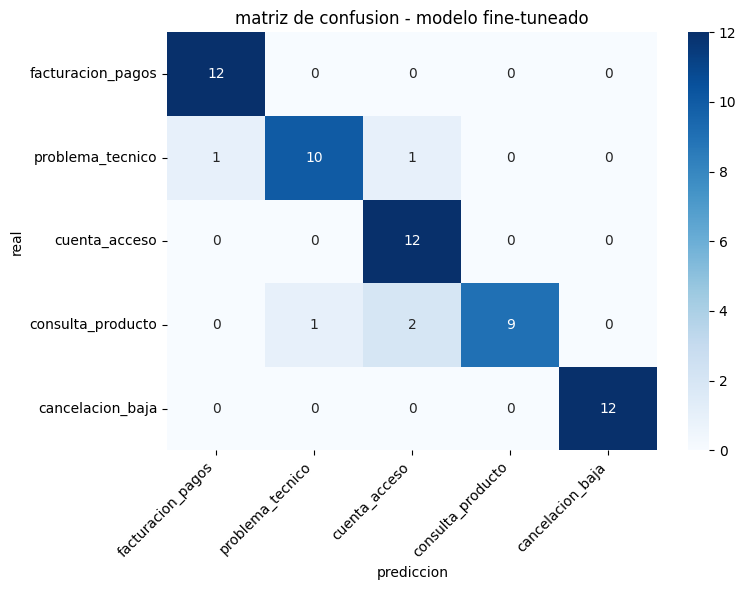

In [ ]:
# matriz de confusion
cm = confusion_matrix(y_test, preds_finetuned, labels=CATEGORIAS)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CATEGORIAS, yticklabels=CATEGORIAS)
plt.xlabel("prediccion")
plt.ylabel("real")
plt.title("matriz de confusion - modelo fine-tuneado")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("matriz_confusion.png", dpi=150)
plt.show()

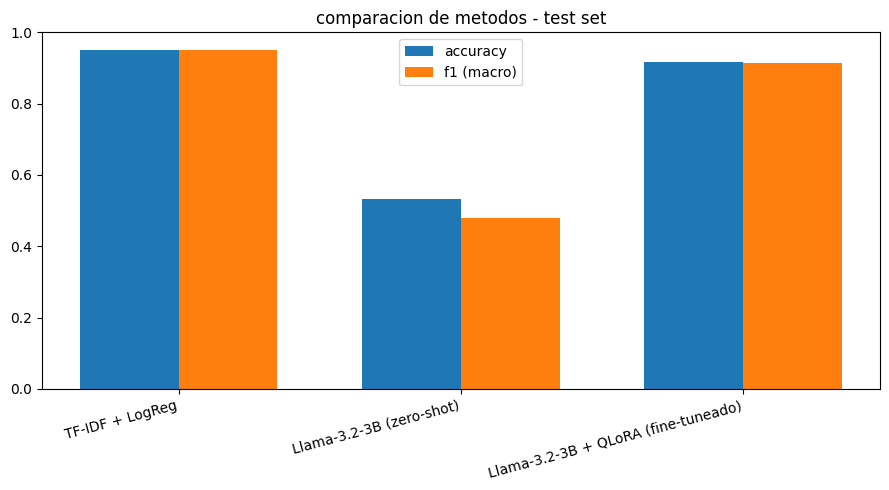

In [ ]:
# grafico comparando los 3 metodos
metodos = list(resultados.keys())
accuracies = [resultados[m]["accuracy"] for m in metodos]
f1s = [resultados[m]["f1_macro"] for m in metodos]

x = np.arange(len(metodos))
width = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, accuracies, width, label="accuracy")
ax.bar(x + width/2, f1s, width, label="f1 (macro)")
ax.set_xticks(x)
ax.set_xticklabels(metodos, rotation=15, ha="right")
ax.set_ylim(0, 1)
ax.legend()
ax.set_title("comparacion de metodos - test set")
plt.tight_layout()
plt.savefig("comparacion_metodos.png", dpi=150)
plt.show()

In [ ]:
# guardar resultados para el README
resumen = {
    nombre: {"accuracy": r["accuracy"], "f1_macro": r["f1_macro"]}
    for nombre, r in resultados.items()
}
with open("resultados_evaluacion.json", "w", encoding="utf-8") as f:
    json.dump(resumen, f, indent=2, ensure_ascii=False)

print("guardado en resultados_evaluacion.json")

guardado en resultados_evaluacion.json


In [ ]:
from google.colab import files

files.download('matriz_confusion.png')
files.download('comparacion_metodos.png')
files.download('resultados_evaluacion.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>